# Segmentasi Seller dan Pelanggan Menggunakan K-Means Clustering
**World Model for Business (Kasus Marketplace Olist)**  

---
Tujuan: Mengidentifikasi arketipe perilaku *seller* dan *pelanggan* secara kuantitatif menggunakan algoritma **K-Means Clustering**, serta memvalidasi stabilitas klaster lintas kurun waktu untuk memastikan keandalan segmentasi dalam pengambilan keputusan bisnis.

In [1]:
import sys
from pathlib import Path

# Tambahkan root project ke sys.path
root_dir = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

from src.data.loader import load_dev_orders

sns.set_theme(style='whitegrid', palette='muted')

# Muat data development
df = load_dev_orders()
print(f'Total Data Dev : {len(df):,} baris pesanan')

Total Data Dev : 86,283 baris pesanan


## 1. Segmentasi Seller Berdasarkan Karakteristik Operasional
Fitur yang digunakan: Volume Penjualan (`order_count`), Total Pendapatan (`total_revenue`), Tingkat Keterlambatan (`late_rate`), Rasio Ulasan Buruk (`bad_review_rate`), dan Durasi Pengemasan Barang (`avg_handling_days`).

Jumlah seller aktif untuk dianalisis (>= 5 pesanan): 1,527


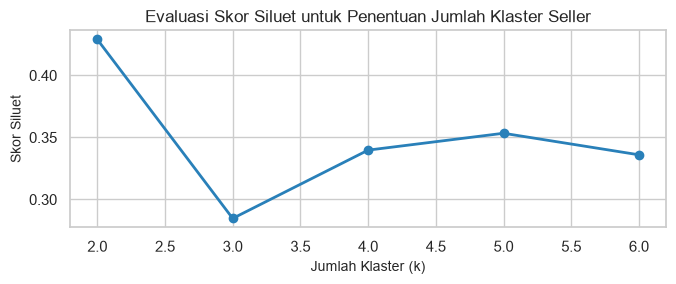

Dipilih k=4 untuk membedakan arketipe: Seller Volume Tinggi, Seller Cepat, Seller Menengah, dan Seller Lambat/Bermasalah.


In [2]:
def get_seller_stats(data, min_orders=5):
    stats = data.groupby('primary_seller_id').agg(
        order_count=('order_id', 'count'),
        total_revenue=('total_payment_value', 'sum'),
        late_rate=('is_late', 'mean'),
        bad_review_rate=('is_bad_review', 'mean'),
        avg_handling_days=('seller_handling_days', 'mean')
    ).dropna()
    return stats[stats['order_count'] >= min_orders]

seller_stats = get_seller_stats(df)
print(f"Jumlah seller aktif untuk dianalisis (>= 5 pesanan): {len(seller_stats):,}")

scaler_seller = StandardScaler()
X_seller = scaler_seller.fit_transform(seller_stats)

# Evaluasi jumlah k optimal dengan Silhouette Score
sil_scores = []
for k in range(2, 7):
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_temp.fit_predict(X_seller)
    sil_scores.append(silhouette_score(X_seller, labels))

plt.figure(figsize=(7, 3))
plt.plot(range(2, 7), sil_scores, marker='o', color='#2980B9', linewidth=2)
plt.title('Evaluasi Skor Siluet untuk Penentuan Jumlah Klaster Seller', fontsize=12)
plt.xlabel('Jumlah Klaster (k)', fontsize=10)
plt.ylabel('Skor Siluet', fontsize=10)
plt.tight_layout()
plt.show()

print("Dipilih k=4 untuk membedakan arketipe: Seller Volume Tinggi, Seller Cepat, Seller Menengah, dan Seller Lambat/Bermasalah.")

In [3]:
# Clustering final seller dengan k=4
kmeans_seller = KMeans(n_clusters=4, random_state=42)
seller_stats['cluster'] = kmeans_seller.fit_predict(X_seller)

seller_profile = seller_stats.groupby('cluster').mean()
seller_profile['seller_count'] = seller_stats.groupby('cluster').size()
seller_profile.round(3)

,order_count,total_revenue,late_rate,bad_review_rate,avg_handling_days,seller_count
cluster,,,,,,
0,46.866,7164.909,0.047,0.092,2.569,1044
1,32.370,5450.819,0.151,0.254,4.456,413
2,19.532,5316.913,0.357,0.439,12.802,47
3,872.565,137164.549,0.084,0.144,3.285,23


### Uji Stabilitas Temporal Klaster Seller (2017 vs 2018)
Untuk memastikan klaster bukan merupakan artefak acak pada satu kurun waktu tertentu, kita melakukan validasi stabilitas temporal dengan membagi data menjadi dua periode: Periode 1 (2017) dan Periode 2 (2018).

In [4]:
df_p1 = df[df['order_purchase_timestamp'].dt.year == 2017]
df_p2 = df[df['order_purchase_timestamp'].dt.year == 2018]

stats_p1 = get_seller_stats(df_p1)
stats_p2 = get_seller_stats(df_p2)

kmeans_p1 = KMeans(n_clusters=4, random_state=42).fit(StandardScaler().fit_transform(stats_p1))
kmeans_p2 = KMeans(n_clusters=4, random_state=42).fit(StandardScaler().fit_transform(stats_p2))

stats_p1['cluster'] = kmeans_p1.labels_
stats_p2['cluster'] = kmeans_p2.labels_

print("Profil Rata-rata Periode 1 (2017):")
display(stats_p1.groupby('cluster').mean().round(3).assign(seller_count=stats_p1['cluster'].value_counts()))
print("\nProfil Rata-rata Periode 2 (2018):")
display(stats_p2.groupby('cluster').mean().round(3).assign(seller_count=stats_p2['cluster'].value_counts()))

Profil Rata-rata Periode 1 (2017):


,order_count,total_revenue,late_rate,bad_review_rate,avg_handling_days,seller_count
cluster,,,,,,
0,28.180,4646.035,0.122,0.232,4.714,294
1,522.150,92657.904,0.064,0.122,3.220,20
2,38.229,5380.424,0.031,0.080,2.743,624
3,13.708,5158.922,0.435,0.493,14.376,24



Profil Rata-rata Periode 2 (2018):


,order_count,total_revenue,late_rate,bad_review_rate,avg_handling_days,seller_count
cluster,,,,,,
0,18.816,4153.904,0.298,0.427,13.163,38
1,34.325,6143.684,0.172,0.248,3.611,375
2,25.120,3702.636,0.046,0.084,2.422,661
3,502.611,69485.828,0.107,0.159,3.314,18


> **Kesimpulan Uji Stabilitas Seller**: Kedua kurun waktu secara konsisten mereproduksi struktur profil yang sama: (1) Seller Normal Cepat dengan handling time rendah, (2) Seller Skala Besar berkinerja tinggi, (3) Seller dengan Handling Time sangat tinggi (>12 hari), dan (4) Seller Skala Menengah. Ini membuktikan bahwa segmentasi seller memiliki stabilitas struktural yang kokoh antar waktu.

## 2. Segmentasi Pelanggan Berdasarkan Nilai Transaksi & Kepuasan
Pada platform Olist, tingkat pembelian ulang sangat rendah (~3%), sehingga mayoritas pembeli adalah pelanggan transaksi tunggal (*one-off buyers*). Oleh karena itu, segmentasi difokuskan pada tiga variabel kunci: Total Pengeluaran (`total_spent`), Rata-rata Skor Ulasan (`avg_score`), dan Jumlah Barang (`total_items`).

In [5]:
cust_stats = df.groupby('customer_unique_id').agg(
    total_spent=('total_payment_value', 'sum'),
    avg_score=('avg_review_score', 'mean'),
    total_items=('item_count', 'sum')
).dropna()

# Filter batas atas nilai ekstrem (<= R$ 2.000) untuk memetakan populasi utama
cust_stats = cust_stats[cust_stats['total_spent'] <= 2000]

X_cust = StandardScaler().fit_transform(cust_stats)
kmeans_cust = KMeans(n_clusters=3, random_state=42)
cust_stats['cluster'] = kmeans_cust.fit_predict(X_cust)

cust_profile = cust_stats.groupby('cluster').mean()
cust_profile['cust_count'] = cust_stats['cluster'].value_counts()
cust_profile.round(2)

,total_spent,avg_score,total_items,cust_count
cluster,,,,
0,136.40,1.86,1.12,18039
1,123.85,4.74,1.07,58955
2,620.73,3.97,2.38,5606


> **Interpretasi Segmen Pelanggan [Data]**:
> - **Klaster 0 (Pelanggan Kecewa / Rating Rendah)**: Rata-rata belanja R$ 136,40 dengan rating rata-rata sangat rendah yaitu **1,86** (mencakup 18.039 pelanggan). Kelompok ini mengalami friksi transaksi atau logistik yang parah.
> - **Klaster 1 (Pelanggan Puas Standar)**: Rata-rata belanja R$ 123,85 dengan tingkat kepuasan tinggi yaitu **4,74** (mencakup 58.955 pelanggan / kelompok mayoritas).
> - **Klaster 2 (Pembelanja Bernilai Tinggi / High-Value)**: Rata-rata belanja tinggi sebesar **R$ 620,73**, keranjang 2,38 item, dengan rating yang baik yaitu **3,97** (mencakup 5.606 pelanggan).

---
## 3. Ringkasan Eksekutif & Rekomendasi Strategis

| Segmen Entitas | Temuan Profil Kunci [Data] | Rekomendasi Bisnis & Kebijakan Platform |
|---|---|---|
| **Seller Handling Tinggi** | Rata-rata handling days 12–14 hari, pemicu late rate 35% | Tetapkan penalti penundaan dan batas waktu penyerahan paket maksimal 3 hari |
| **Seller Utama (Top Volume)** | Menangani ratusan pesanan dengan handling time cepat (3 hari) | Berikan insentif biaya platform dan prioritas integrasi kurir express |
| **Pelanggan Puas (Klaster 1)** | 58.955 pelanggan dengan rating tinggi (4,74) | Salurkan program email loyalitas dan promosi kategori komplementer |
| **Pelanggan Kecewa (Klaster 0)** | 18.039 pelanggan dengan rating buruk (1,86) | Bentuk tim Customer Recovery dan voucher kompensasi sebelum churn permanen |